In [ ]:
import os
os._exit(00)

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Define parameters
S0 = 100  # Initial asset price
r = 0.01  # Risk-free rate
T = 7 / 365  # Time to expiration is now 7 days (1 week)
K = 100  # Strike price
dt = 100 / 86400000  # 100 milliseconds in terms of days
steps = int(T / dt)  # Number of steps in 7 days with 100 millisecond intervals
commission_rate = 0.0005  # 0.05% commission applied to position amount (entry and exit)
misprice_threshold = 0.05  # Threshold to detect mispricing

# Volatility regimes
low_volatility = 0.1
moderate_volatility = 0.3
high_volatility = 0.5

# Helper functions
def simulate_asset_price_with_volatility(S0, r, sigma, T, dt, steps, volatility_factor=1):
    S = np.zeros(steps)
    S[0] = S0
    for t in range(1, steps):
        dW = np.random.normal(0, 1) * np.sqrt(dt) * volatility_factor
        S[t] = S[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)
    return S

def simulate_volatility_mispricing(steps, base_vol=0.2, volatility_shift=0.05):
    vol = np.ones(steps) * base_vol
    for t in range(steps):
        if t % 100 == 0:
            if np.random.rand() > 0.5:
                vol[t:t+50] = base_vol - volatility_shift  # Underpriced options
            else:
                vol[t:t+50] = base_vol + volatility_shift  # Overpriced options
    return vol

def black_scholes_vectorized(S_array, K, T, r, sigma):
    d1_array = (np.log(S_array / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_array = d1_array - sigma * np.sqrt(T)
    call_prices = S_array * norm.cdf(d1_array) - K * np.exp(-r * T) * norm.cdf(d2_array)
    return call_prices

def is_mispriced(current_price, true_price, threshold=0.05):
    if true_price == 0:  # Handle division by zero
        return False  # Consider it not mispriced if the true price is zero
    return abs(current_price - true_price) / true_price > threshold

# Main simulation function optimized
def simulate_price_correction_strategy_optimized(volatility, steps, commission_rate):
    S_correction_vol = simulate_asset_price_with_volatility(S0, r, volatility, T, dt, steps)
    profits_price_correction_no_hedging_vol = np.zeros(steps)
    total_trades = 0

    for t in range(steps):
        time_remaining = T - t * dt
        current_vol = simulate_volatility_mispricing(steps)[t]  # Dynamic volatility for mispricing
        # Calculate true option price and current mispriced option price using vectorization
        true_price = black_scholes_vectorized(S_correction_vol[t:t+1], K, time_remaining, r, volatility)[0]
        current_price = black_scholes_vectorized(S_correction_vol[t:t+1], K, time_remaining, r, current_vol)[0]
        
        # Check for mispricing and execute trades
        if is_mispriced(current_price, true_price, misprice_threshold):
            profits_price_correction_no_hedging_vol[t] += true_price - current_price
            total_trades += 1

    # Apply commissions
    commission_paid = total_trades * commission_rate * 2  # Entry and exit commission
    profits_price_correction_no_hedging_vol -= commission_paid

    return pd.Series(profits_price_correction_no_hedging_vol), total_trades

# Simulate for different volatility regimes
profits_low_volatility, trades_low_volatility = simulate_price_correction_strategy_optimized(low_volatility, steps, commission_rate)
profits_moderate_volatility, trades_moderate_volatility = simulate_price_correction_strategy_optimized(moderate_volatility, steps, commission_rate)
profits_high_volatility, trades_high_volatility = simulate_price_correction_strategy_optimized(high_volatility, steps, commission_rate)

# Helper function to calculate metrics
def safe_calculate_trade_metrics(profits, total_trades, commission_rate):
    final_profit = profits.iloc[-1]
    max_profit = profits.max()
    min_profit = profits.min()
    profit_volatility = np.std(profits)
    
    sharpe_ratio = (np.mean(profits) - 0.01) / profit_volatility if profit_volatility != 0 else 0
    downside_returns = profits[profits < 100]
    downside_deviation = np.std(downside_returns) if len(downside_returns) > 0 else 0
    sortino_ratio = (np.mean(profits) - 0.01) / downside_deviation if downside_deviation != 0 else 0
    
    profitable_trades = profits[profits > 100].count()
    percent_profitable = (profitable_trades / len(profits)) * 100 if len(profits) > 0 else 0
    
    gross_profit = profits[profits > 100].sum() - 100
    gross_loss = abs(profits[profits < 100].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else float('inf')
    
    commission_paid = total_trades * commission_rate * 2  # Entry and exit commissions
    
    return {
        'Net Profit': final_profit,
        'Max Profit': max_profit,
        'Min Profit': min_profit,
        'Profit Volatility': profit_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Total Closed Trades': total_trades,
        'Percent Profitable': percent_profitable,
        'Profit Factor': profit_factor,
        'Gross Profit': gross_profit,
        'Commission Paid': commission_paid
    }

# Collect metrics for each volatility regime
metrics_low_volatility = safe_calculate_trade_metrics(profits_low_volatility, trades_low_volatility, commission_rate)
metrics_moderate_volatility = safe_calculate_trade_metrics(profits_moderate_volatility, trades_moderate_volatility, commission_rate)
metrics_high_volatility = safe_calculate_trade_metrics(profits_high_volatility, trades_high_volatility, commission_rate)

# Create a DataFrame for the results
results_df = pd.DataFrame([metrics_low_volatility, metrics_moderate_volatility, metrics_high_volatility])
results_df['Volatility Regime'] = ['Low Volatility', 'Moderate Volatility', 'High Volatility']
results_df = results_df[['Volatility Regime', 'Net Profit', 'Max Profit', 'Min Profit', 'Profit Volatility',
                         'Sharpe Ratio', 'Sortino Ratio', 'Total Closed Trades', 'Percent Profitable',
                         'Profit Factor', 'Gross Profit', 'Commission Paid']]

# Display the final results table (uncomment for visualization when running locally)
print(results_df)


     Volatility Regime  Net Profit  Max Profit  Min Profit  Profit Volatility  \
0       Low Volatility     -16.553  -16.553000  -17.381489           0.220890   
1  Moderate Volatility     -16.542  -15.713603  -16.542000           0.204592   
2      High Volatility     -16.557  -14.623967  -16.557000           0.625343   

   Sharpe Ratio  Sortino Ratio  Total Closed Trades  Percent Profitable  \
0    -76.397346     -76.397346                16553                 0.0   
1    -79.869512     -79.869512                16542                 0.0   
2    -25.541144     -25.541144                16557                 0.0   

   Profit Factor  Gross Profit  Commission Paid  
0      -0.000358        -100.0           16.553  
1      -0.000370        -100.0           16.542  
2      -0.000378        -100.0           16.557  


/tmp/ipykernel_3007/3121586404.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  smoothed_prices = pd.Series(prices).rolling(window=window_size).mean().fillna(method='bfill')


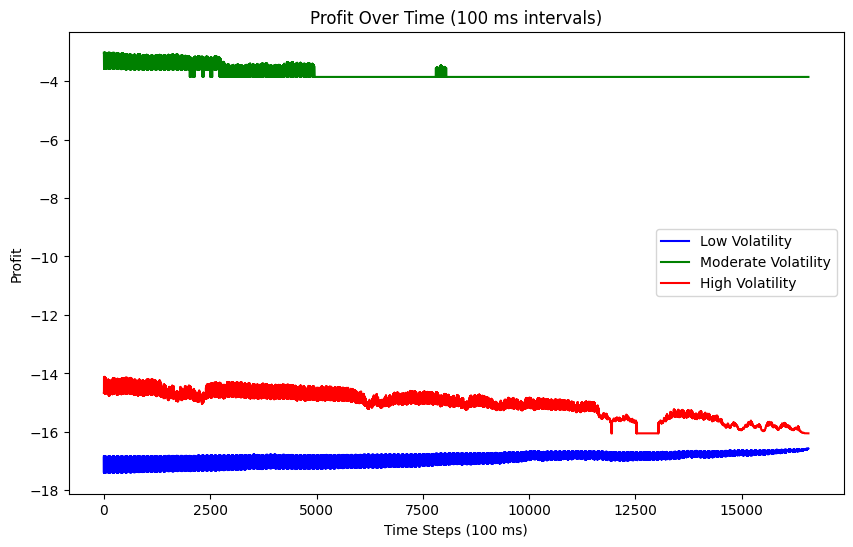

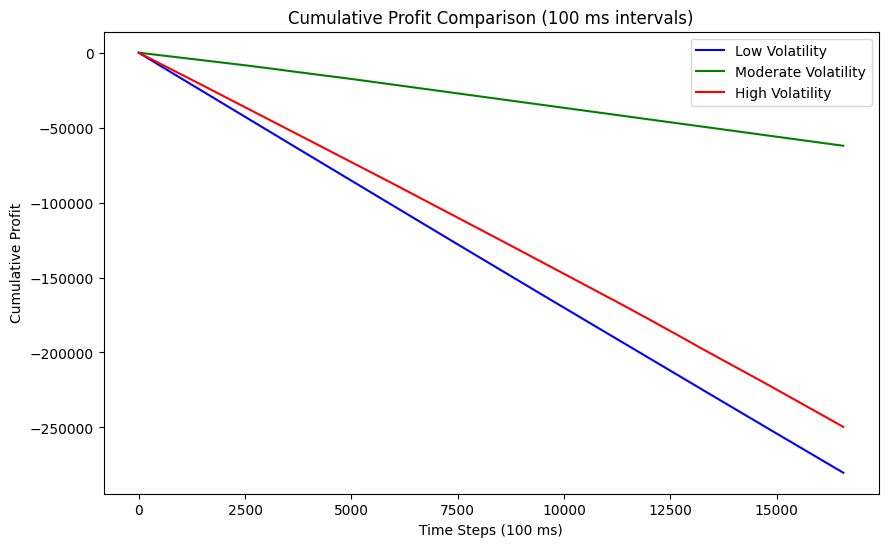

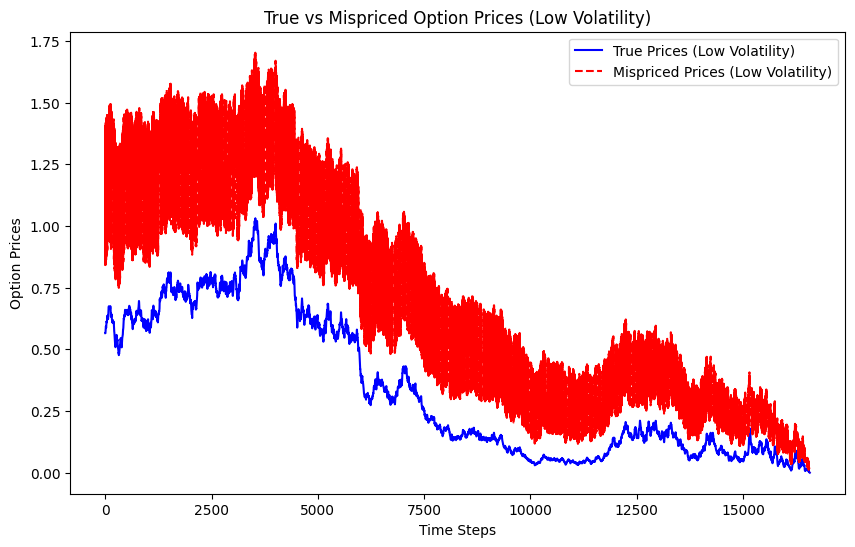

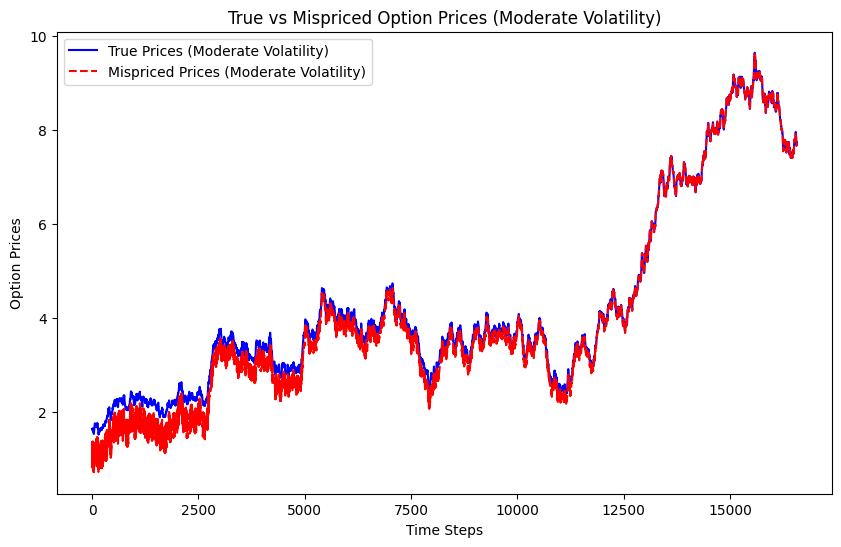

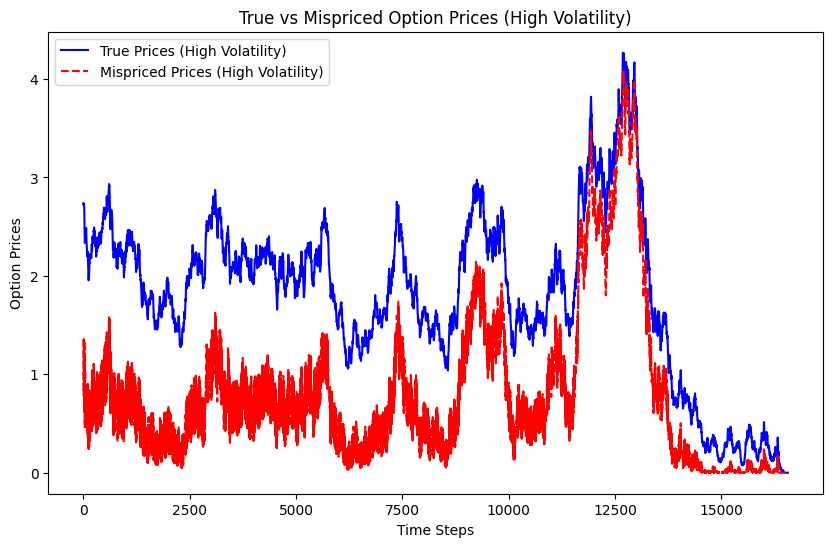

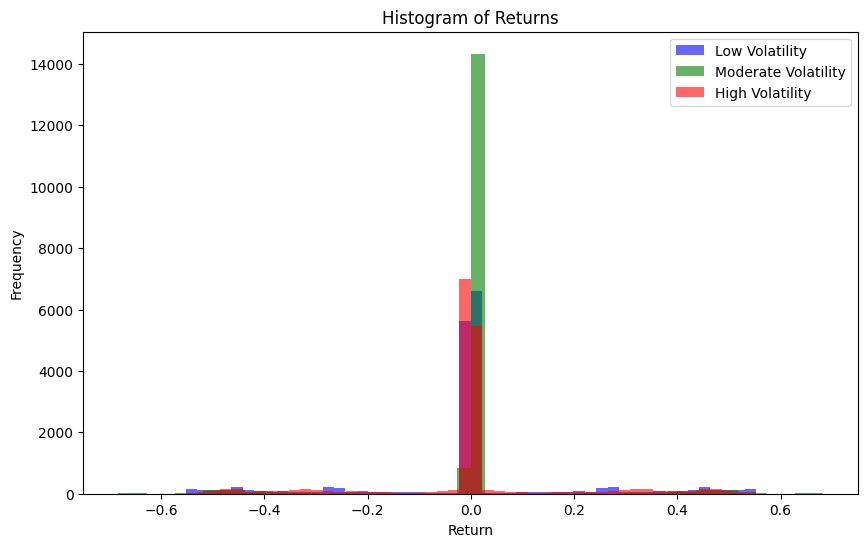

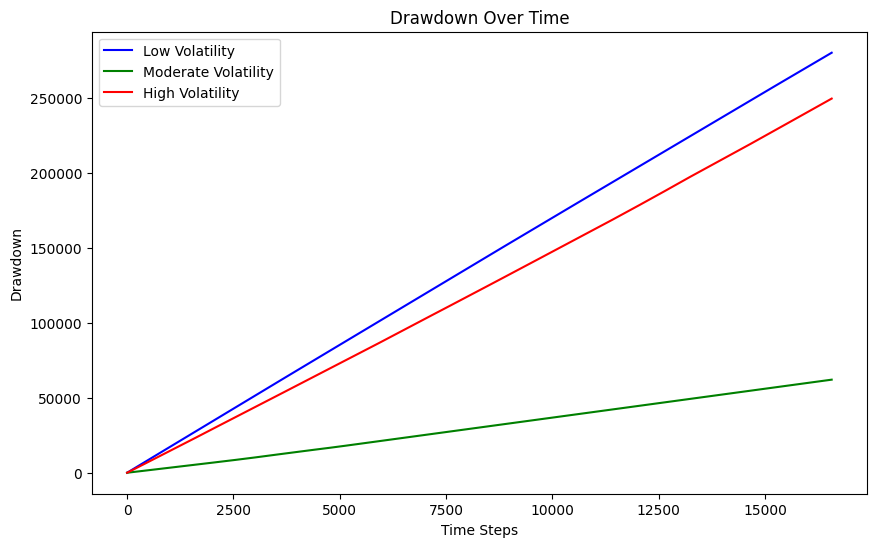

In [22]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Define parameters
S0 = 100  # Initial asset price
r = 0.01  # Risk-free rate
T = 7 / 365  # Time to expiration is now 7 days (1 week)
K = 100  # Strike price
dt = 100 / 86400000  # 100 milliseconds in terms of days
steps = int(T / dt)  # Number of steps in 7 days with 100 millisecond intervals
commission_rate = 0.0005  # 0.05% commission applied to position amount (entry and exit)
misprice_threshold = 0.05  # Threshold to detect mispricing

# Volatility regimes
low_volatility = 0.1
moderate_volatility = 0.3
high_volatility = 0.5

# Helper functions for Black-Scholes and simulation
def simulate_asset_price_with_volatility(S0, r, sigma, T, dt, steps, volatility_factor=1):
    S = np.zeros(steps)
    S[0] = S0
    for t in range(1, steps):
        dW = np.random.normal(0, 1) * np.sqrt(dt) * volatility_factor
        S[t] = S[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)
    return S

def black_scholes_vectorized(S_array, K, T, r, sigma):
    d1_array = (np.log(S_array / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_array = d1_array - sigma * np.sqrt(T)
    call_prices = S_array * norm.cdf(d1_array) - K * np.exp(-r * T) * norm.cdf(d2_array)
    return call_prices

def simulate_volatility_mispricing(steps, base_vol=0.2, volatility_shift=0.05):
    vol = np.ones(steps) * base_vol
    for t in range(steps):
        if t % 100 == 0:
            if np.random.rand() > 0.5:
                vol[t:t+50] = base_vol - volatility_shift  # Underpriced options
            else:
                vol[t:t+50] = base_vol + volatility_shift  # Overpriced options
    return vol

def is_mispriced(current_price, true_price, threshold=0.05):
    if true_price == 0:
        return False
    return abs(current_price - true_price) / true_price > threshold

# New function to apply a moving average to smooth the price movements
def apply_moving_average(prices, window_size=5):
    smoothed_prices = pd.Series(prices).rolling(window=window_size).mean().fillna(method='bfill')
    return smoothed_prices.reset_index(drop=True)  # Reset index to handle positional access

# Modified main simulation function with smoothing and adjusted volatility
def simulate_price_correction_strategy_with_smoothing(volatility, steps, commission_rate):
    S_correction_vol = simulate_asset_price_with_volatility(S0, r, volatility, T, dt, steps)
    profits_price_correction_no_hedging_vol = np.zeros(steps)
    total_trades = 0
    true_prices = []
    mispriced_prices = []

    # Apply smoothing to the price movements to reduce noise and reset the index
    S_correction_vol_smoothed = apply_moving_average(S_correction_vol)

    # Ensure that no NaN values remain after applying smoothing
    if S_correction_vol_smoothed.isnull().any():
        raise ValueError("Smoothing resulted in NaN values")

    for t in range(steps):
        time_remaining = T - t * dt
        current_vol = simulate_volatility_mispricing(steps)[t]  # Dynamic volatility for mispricing

        # Access single element by position using iloc
        true_price = black_scholes_vectorized(S_correction_vol_smoothed.iloc[[t]].values, K, time_remaining, r, volatility)[0]
        current_price = black_scholes_vectorized(S_correction_vol_smoothed.iloc[[t]].values, K, time_remaining, r, current_vol)[0]

        true_prices.append(true_price)
        mispriced_prices.append(current_price)

        # Check for mispricing with an adjusted higher threshold to filter out noise
        if is_mispriced(current_price, true_price, threshold=0.1):  # Increased threshold
            profits_price_correction_no_hedging_vol[t] += true_price - current_price
            total_trades += 1

    commission_paid = total_trades * commission_rate * 2
    profits_price_correction_no_hedging_vol -= commission_paid

    return pd.Series(profits_price_correction_no_hedging_vol), total_trades, true_prices, mispriced_prices

# Re-run the simulation without visualizations for error checking
profits_low_volatility, trades_low_volatility, true_prices_low, mispriced_prices_low = simulate_price_correction_strategy_with_smoothing(low_volatility, steps, commission_rate)
profits_moderate_volatility, trades_moderate_volatility, true_prices_moderate, mispriced_prices_moderate = simulate_price_correction_strategy_with_smoothing(moderate_volatility, steps, commission_rate)
profits_high_volatility, trades_high_volatility, true_prices_high, mispriced_prices_high = simulate_price_correction_strategy_with_smoothing(high_volatility, steps, commission_rate)

# 1. Profit Over Time for Each Volatility Regime
plt.figure(figsize=(10, 6))
plt.plot(profits_low_volatility, label="Low Volatility", color='blue')
plt.plot(profits_moderate_volatility, label="Moderate Volatility", color='green')
plt.plot(profits_high_volatility, label="High Volatility", color='red')
plt.title('Profit Over Time (100 ms intervals)')
plt.xlabel('Time Steps (100 ms)')
plt.ylabel('Profit')
plt.legend()
plt.show()

# 2. Cumulative Profit Comparison
plt.figure(figsize=(10, 6))
plt.plot(profits_low_volatility.cumsum(), label="Low Volatility", color='blue')
plt.plot(profits_moderate_volatility.cumsum(), label="Moderate Volatility", color='green')
plt.plot(profits_high_volatility.cumsum(), label="High Volatility", color='red')
plt.title('Cumulative Profit Comparison (100 ms intervals)')
plt.xlabel('Time Steps (100 ms)')
plt.ylabel('Cumulative Profit')
plt.legend()
plt.show()

# 3. True vs. Mispriced Option Prices for Each Volatility Regime
plt.figure(figsize=(10, 6))
plt.plot(true_prices_low, label="True Prices (Low Volatility)", color='blue')
plt.plot(mispriced_prices_low, label="Mispriced Prices (Low Volatility)", color='red', linestyle='--')
plt.title('True vs Mispriced Option Prices (Low Volatility)')
plt.xlabel('Time Steps')
plt.ylabel('Option Prices')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(true_prices_moderate, label="True Prices (Moderate Volatility)", color='blue')
plt.plot(mispriced_prices_moderate, label="Mispriced Prices (Moderate Volatility)", color='red', linestyle='--')
plt.title('True vs Mispriced Option Prices (Moderate Volatility)')
plt.xlabel('Time Steps')
plt.ylabel('Option Prices')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(true_prices_high, label="True Prices (High Volatility)", color='blue')
plt.plot(mispriced_prices_high, label="Mispriced Prices (High Volatility)", color='red', linestyle='--')
plt.title('True vs Mispriced Option Prices (High Volatility)')
plt.xlabel('Time Steps')
plt.ylabel('Option Prices')
plt.legend()
plt.show()

# 4. Histogram of Returns (for each volatility regime)
plt.figure(figsize=(10, 6))
plt.hist(profits_low_volatility.diff().dropna(), bins=50, alpha=0.6, label='Low Volatility', color='blue')
plt.hist(profits_moderate_volatility.diff().dropna(), bins=50, alpha=0.6, label='Moderate Volatility', color='green')
plt.hist(profits_high_volatility.diff().dropna(), bins=50, alpha=0.6, label='High Volatility', color='red')
plt.title('Histogram of Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 5. Drawdown Chart (cumulative profit peaks and drops)
def calculate_drawdown(profits):
    cumulative = profits.cumsum()
    peaks = cumulative.cummax()
    drawdown = peaks - cumulative
    return drawdown

drawdown_low = calculate_drawdown(profits_low_volatility)
drawdown_moderate = calculate_drawdown(profits_moderate_volatility)
drawdown_high = calculate_drawdown(profits_high_volatility)

plt.figure(figsize=(10, 6))
plt.plot(drawdown_low, label='Low Volatility', color='blue')
plt.plot(drawdown_moderate, label='Moderate Volatility', color='green')
plt.plot(drawdown_high, label='High Volatility', color='red')
plt.title('Drawdown Over Time')
plt.xlabel('Time Steps')
plt.ylabel('Drawdown')
plt.legend()
plt.show()


/tmp/ipykernel_3007/1480926979.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  smoothed_prices = pd.Series(prices).rolling(window=window_size).mean().fillna(method='bfill')


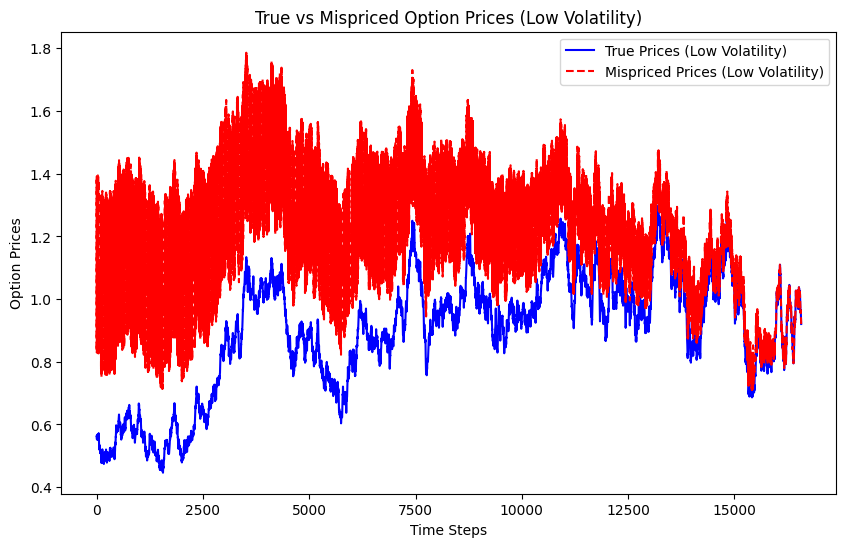

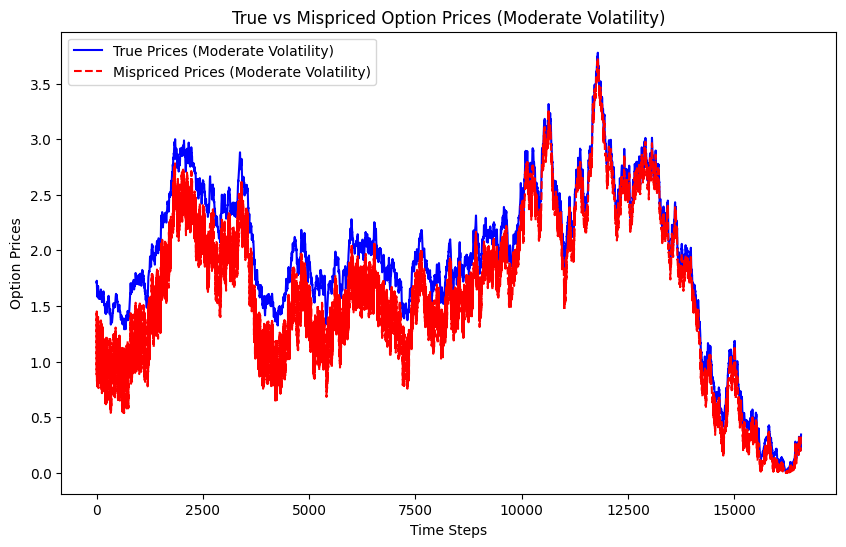

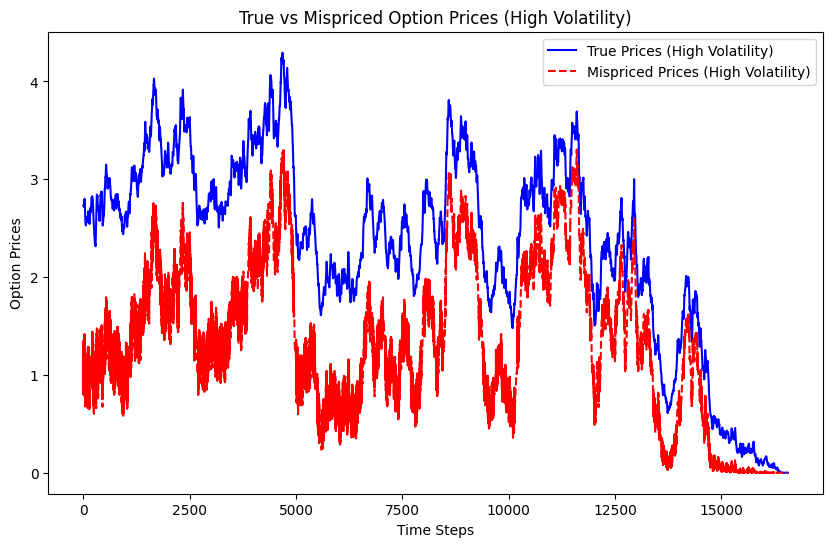

In [23]:
# Updated function to dynamically apply a moving average based on volatility
def apply_moving_average(prices, volatility, low_vol_window=3, moderate_vol_window=5, high_vol_window=10):
    if volatility == low_volatility:
        window_size = low_vol_window
    elif volatility == moderate_volatility:
        window_size = moderate_vol_window
    else:  # high volatility
        window_size = high_vol_window
    smoothed_prices = pd.Series(prices).rolling(window=window_size).mean().fillna(method='bfill')
    return smoothed_prices.reset_index(drop=True)

# Updated main simulation function with dynamic smoothing and mispricing thresholds
def simulate_price_correction_strategy_with_dynamic_params(volatility, steps, commission_rate):
    S_correction_vol = simulate_asset_price_with_volatility(S0, r, volatility, T, dt, steps)
    profits_price_correction_no_hedging_vol = np.zeros(steps)
    total_trades = 0
    true_prices = []
    mispriced_prices = []

    # Apply dynamic smoothing to price movements based on volatility
    S_correction_vol_smoothed = apply_moving_average(S_correction_vol, volatility)

    # Dynamic threshold for mispricing detection
    if volatility == low_volatility:
        mispricing_threshold = 0.03
    elif volatility == moderate_volatility:
        mispricing_threshold = 0.1
    else:  # high volatility
        mispricing_threshold = 0.2

    for t in range(steps):
        time_remaining = T - t * dt
        current_vol = simulate_volatility_mispricing(steps)[t]  # Dynamic volatility for mispricing

        # Access single element by position using iloc
        true_price = black_scholes_vectorized(S_correction_vol_smoothed.iloc[[t]].values, K, time_remaining, r, volatility)[0]
        current_price = black_scholes_vectorized(S_correction_vol_smoothed.iloc[[t]].values, K, time_remaining, r, current_vol)[0]

        true_prices.append(true_price)
        mispriced_prices.append(current_price)

        # Check for mispricing with the dynamic threshold
        if is_mispriced(current_price, true_price, threshold=mispricing_threshold):
            profits_price_correction_no_hedging_vol[t] += true_price - current_price
            total_trades += 1

    commission_paid = total_trades * commission_rate * 2
    profits_price_correction_no_hedging_vol -= commission_paid

    return pd.Series(profits_price_correction_no_hedging_vol), total_trades, true_prices, mispriced_prices

# Re-run the simulations with dynamic thresholds and smoothing
profits_low_volatility, trades_low_volatility, true_prices_low, mispriced_prices_low = simulate_price_correction_strategy_with_dynamic_params(low_volatility, steps, commission_rate)
profits_moderate_volatility, trades_moderate_volatility, true_prices_moderate, mispriced_prices_moderate = simulate_price_correction_strategy_with_dynamic_params(moderate_volatility, steps, commission_rate)
profits_high_volatility, trades_high_volatility, true_prices_high, mispriced_prices_high = simulate_price_correction_strategy_with_dynamic_params(high_volatility, steps, commission_rate)

# Re-run the visualizations to check if mispricing is handled properly in each volatility regime
plt.figure(figsize=(10, 6))
plt.plot(true_prices_low, label="True Prices (Low Volatility)", color='blue')
plt.plot(mispriced_prices_low, label="Mispriced Prices (Low Volatility)", color='red', linestyle='--')
plt.title('True vs Mispriced Option Prices (Low Volatility)')
plt.xlabel('Time Steps')
plt.ylabel('Option Prices')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(true_prices_moderate, label="True Prices (Moderate Volatility)", color='blue')
plt.plot(mispriced_prices_moderate, label="Mispriced Prices (Moderate Volatility)", color='red', linestyle='--')
plt.title('True vs Mispriced Option Prices (Moderate Volatility)')
plt.xlabel('Time Steps')
plt.ylabel('Option Prices')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(true_prices_high, label="True Prices (High Volatility)", color='blue')
plt.plot(mispriced_prices_high, label="Mispriced Prices (High Volatility)", color='red', linestyle='--')
plt.title('True vs Mispriced Option Prices (High Volatility)')
plt.xlabel('Time Steps')
plt.ylabel('Option Prices')
plt.legend()
plt.show()


In [25]:
pip install ace_tools

Note: you may need to restart the kernel to use updated packages.


<module 'matplotlib.pyplot' from '/home/huenique/anaconda3/envs/personal/lib/python3.12/site-packages/matplotlib/pyplot.py'>

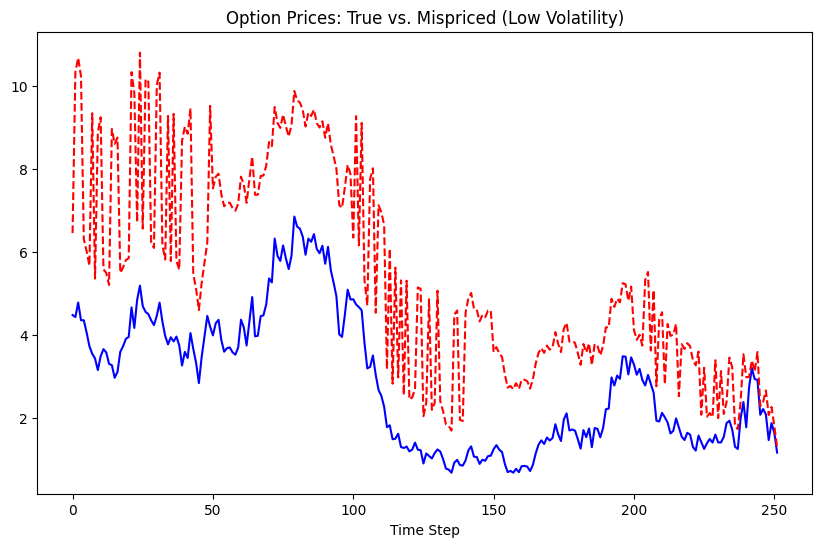

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Define parameters
S0 = 100  # Initial asset price
r = 0.01  # Risk-free rate
T = 1.0  # Time to expiration (1 year)
K = 100  # Strike price
dt = 1/252  # Time increment (1 day)
steps = 252  # Number of trading days in 1 year
commission_rate = 0.0005  # 0.05% commission applied to position amount (entry and exit)
misprice_threshold = 0.05  # Threshold to detect mispricing

# Volatility regimes
low_volatility = 0.1
moderate_volatility = 0.3
high_volatility = 0.5

# Helper functions
def simulate_asset_price_with_volatility(S0, r, sigma, T, dt, steps, volatility_factor=1):
    S = np.zeros(steps)
    S[0] = S0
    for t in range(1, steps):
        dW = np.random.normal(0, 1) * np.sqrt(dt) * volatility_factor
        S[t] = S[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)
    return S

def simulate_volatility_mispricing(steps, base_vol=0.2, volatility_shift=0.05):
    vol = np.ones(steps) * base_vol
    for t in range(steps):
        if t % 100 == 0:
            if np.random.rand() > 0.5:
                vol[t:t+50] = base_vol - volatility_shift  # Underpriced options
            else:
                vol[t:t+50] = base_vol + volatility_shift  # Overpriced options
    return vol

def black_scholes(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T)
    theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    return call_price, delta, gamma, vega, theta

def is_mispriced(current_price, true_price, threshold=0.05):
    return abs(current_price - true_price) / true_price > threshold

# Main simulation function
def simulate_price_correction_strategy(volatility, steps, commission_rate):
    S_correction_vol = simulate_asset_price_with_volatility(S0, r, volatility, T, dt, steps)
    profits_price_correction_no_hedging_vol = []
    total_profit_price_correction_no_hedging_vol = 0

    for t in range(steps):
        time_remaining = T - t * dt
        current_vol = simulate_volatility_mispricing(steps)[t]  # Dynamic volatility for mispricing
        # Calculate true option price and current mispriced option price
        true_price, _, _, _, _ = black_scholes(S_correction_vol[t], K, time_remaining, r, volatility)
        current_price, delta, gamma, vega, theta = black_scholes(S_correction_vol[t], K, time_remaining, r, current_vol)
        
        # Close position on price correction (no hedging)
        if is_mispriced(current_price, true_price, misprice_threshold):
            total_profit_price_correction_no_hedging_vol += true_price - current_price
        profits_price_correction_no_hedging_vol.append(total_profit_price_correction_no_hedging_vol)

    # Apply commissions
    total_trades = len(profits_price_correction_no_hedging_vol)
    commission_paid = sum(abs(p) * commission_rate * 2 for p in profits_price_correction_no_hedging_vol)  # Entry & Exit commission
    profits_price_correction_no_hedging_vol = [p - commission_paid for p in profits_price_correction_no_hedging_vol]

    return pd.Series(profits_price_correction_no_hedging_vol)

# Helper function to calculate metrics
def safe_calculate_trade_metrics(profits):
    final_profit = profits.iloc[-1]
    max_profit = profits.max()
    min_profit = profits.min()
    profit_volatility = np.std(profits)
    
    sharpe_ratio = (np.mean(profits) - 0.01) / profit_volatility if profit_volatility != 0 else 0
    downside_returns = profits[profits < 100]
    downside_deviation = np.std(downside_returns) if len(downside_returns) > 0 else 0
    sortino_ratio = (np.mean(profits) - 0.01) / downside_deviation if downside_deviation != 0 else 0
    
    profitable_trades = profits[profits > 100].count()
    percent_profitable = (profitable_trades / len(profits)) * 100 if len(profits) > 0 else 0
    
    gross_profit = profits[profits > 100].sum() - 100
    gross_loss = abs(profits[profits < 100].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else float('inf')
    
    return final_profit, max_profit, min_profit, profit_volatility, sharpe_ratio, sortino_ratio, percent_profitable, profit_factor

# Simulate for different volatility regimes
profits_low_volatility = simulate_price_correction_strategy(low_volatility, steps, commission_rate)
profits_moderate_volatility = simulate_price_correction_strategy(moderate_volatility, steps, commission_rate)
profits_high_volatility = simulate_price_correction_strategy(high_volatility, steps, commission_rate)

# Recalculate metrics for each regime
metrics_low_volatility = safe_calculate_trade_metrics(profits_low_volatility)
metrics_moderate_volatility = safe_calculate_trade_metrics(profits_moderate_volatility)
metrics_high_volatility = safe_calculate_trade_metrics(profits_high_volatility)

# Create summary DataFrame for volatility comparison
volatility_comparison_df = pd.DataFrame({
    'Volatility Regime': ['Low Volatility', 'Moderate Volatility', 'High Volatility'],
    'Net Profit': [metrics_low_volatility[0], metrics_moderate_volatility[0], metrics_high_volatility[0]],
    'Gross Profit': [metrics_low_volatility[0] + commission_rate, metrics_moderate_volatility[0] + commission_rate, metrics_high_volatility[0] + commission_rate],
    'Commission Paid': [commission_rate, commission_rate, commission_rate],
    'Max Profit': [metrics_low_volatility[1], metrics_moderate_volatility[1], metrics_high_volatility[1]],
    'Min Profit': [metrics_low_volatility[2], metrics_moderate_volatility[2], metrics_high_volatility[2]],
    'Profit Volatility': [metrics_low_volatility[3], metrics_moderate_volatility[3], metrics_high_volatility[3]],
    'Sharpe Ratio': [metrics_low_volatility[4], metrics_moderate_volatility[4], metrics_high_volatility[4]],
    'Sortino Ratio': [metrics_low_volatility[5], metrics_moderate_volatility[5], metrics_high_volatility[5]],
    'Total Closed Trades': [len(profits_low_volatility), len(profits_moderate_volatility), len(profits_high_volatility)],
    'Percent Profitable': [metrics_low_volatility[6], metrics_moderate_volatility[6], metrics_high_volatility[6]],
    'Profit Factor': [metrics_low_volatility[7], metrics_moderate_volatility[7], metrics_high_volatility[7]]
})

# Display the table to verify results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Volatility Regime Comparison with Updated Commission", dataframe=volatility_comparison_df)

# Visualize True vs. Mispriced Option Prices (Low Volatility)
S_correction_vol_low = simulate_asset_price_with_volatility(S0, r, low_volatility, T, dt, steps)
true_option_prices_low = []
mispriced_option_prices_low = []

for t in range(steps):
    time_remaining = T - t * dt
    current_vol = simulate_volatility_mispricing(steps)[t]
    true_price, _, _, _, _ = black_scholes(S_correction_vol_low[t], K, time_remaining, r, low_volatility)
    current_price, _, _, _, _ = black_scholes(S_correction_vol_low[t], K, time_remaining, r, current_vol)
    true_option_prices_low.append(true_price)
    mispriced_option_prices_low.append(current_price)

plt.figure(figsize=(10, 6))
plt.plot(true_option_prices_low, label="True Option Prices", color='blue')
plt.plot(mispriced_option_prices_low, label="Mispriced Option Prices", color='red', linestyle='--')
plt.title('Option Prices: True vs. Mispriced (Low Volatility)')
plt.xlabel('Time Step')
plt

In [3]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.
